# GHSL — built-up growth (multi-epoch + aggregate)

A GHSL strength is its multi-temporal record. Request GHS-BUILT-S at two epochs (2000 and 2020) and reduce across them with `aggregate=` to map the **maximum** built-up surface — a simple growth proxy.

In [1]:
import tempfile

from earthlens import EarthLens
from earthlens.aggregate import AggregationConfig

out = tempfile.mkdtemp()
growth = EarthLens(
    data_source='ghsl',
    variables=['GHS_BUILT_S'],
    start='2000-01-01',
    end='2020-12-31',
    epochs=[2000, 2020],
    aoi=[-9.20, 38.68, -9.10, 38.78],
    path=out,
).download(progress_bar=False, aggregate=AggregationConfig(freq='100YS', op='max'))
growth

2026-05-28 22:48:02 | INFO | pyramids.base.config | Logging is configured.


2026-05-28 22:48:03 | WARNING | pyramids.base.config.gdal | GDAL[6] Band data type of UInt16 cannot represent the specified NoData value of nan


2026-05-28 22:48:16 | WARNING | pyramids.base.config.gdal | GDAL[6] Band data type of UInt16 cannot represent the specified NoData value of nan


[WindowsPath('C:/Users/main/AppData/Local/Temp/claude/tmpw9o5ddoo/GHS_BUILT_S_max_2000_100m_epsg4326.tif')]

Plot the across-epoch maximum built-up surface:

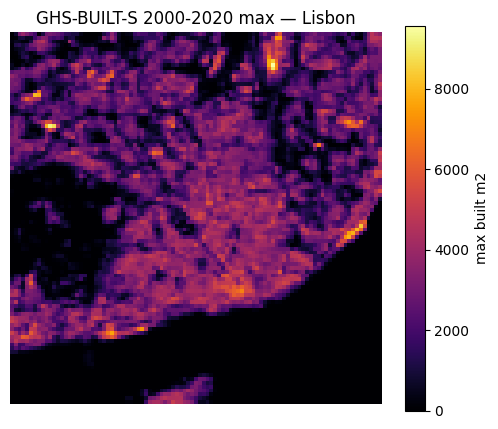

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from pyramids.dataset import Dataset

arr = np.asarray(Dataset.read_file(str(growth[0])).read_array(), dtype='float32')
arr = arr[0] if arr.ndim == 3 else arr
arr = np.where(arr < 0, np.nan, arr)
plt.figure(figsize=(6, 5))
plt.imshow(arr, cmap='inferno')
plt.colorbar(label='max built m2')
plt.title('GHS-BUILT-S 2000-2020 max — Lisbon')
plt.axis('off')
plt.show()